<a href="https://colab.research.google.com/github/githubtaniya924/Image-Processing-Projects/blob/main/IP_Practical9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

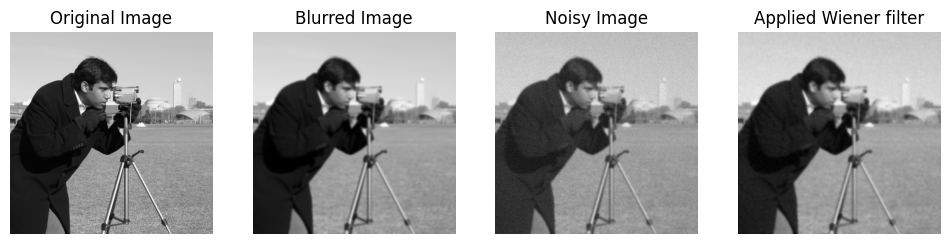

In [ ]:
#Wiener Filter
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import data
from scipy.signal import wiener
from scipy.ndimage import gaussian_filter
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity


#load built-in grayscale image
original = data.camera()

#convert image to float
original = original.astype(np.float64)

#create blured image using gausian blur
blurred = gaussian_filter(original, sigma=2)

#add noise to the blurred image
noise = np.random.normal(0,10,original.shape)
noisy_blurred = blurred + noise

#apply wiener filter
restore = wiener(noisy_blurred, (5,5))

#display result
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.title('Original Image')
plt.imshow(original, cmap='gray')
plt.axis("off")

plt.subplot(1,4,2)
plt.title('Blurred Image')
plt.imshow(blurred, cmap='gray')
plt.axis("off")

plt.subplot(1,4,3)
plt.title('Noisy Image')
plt.imshow(noisy_blurred, cmap='gray')
plt.axis("off")

plt.subplot(1,4,4)
plt.title('Applied Wiener filter')
plt.imshow(restore, cmap='gray')
plt.axis("off")


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

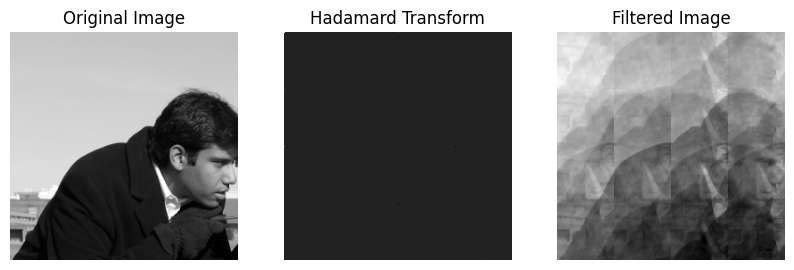

In [ ]:
# Hadamard Filtering
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
from skimage import data
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

# Load a small grayscale image
image = data.camera()
image = image[:256, :256] #make size power of 2
image = image.astype(float)

# Generate Hadamard matrix
N = image.shape[0]
H = hadamard(N)

# Forward Hadamard Transform
hadamard_transform = (H @ image @ H) / N

# Simple low-pass filtering (keep low-frequenct components)
filtered_transform = hadamard_transform.copy()
filtered_transform[50:, 50:] = 0 # remove high_frequency details

#inverse hadamard transform
reconstructed = (H.T @ filtered_transform @ H)/N

#display result
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title('Hadamard Transform')
plt.imshow(hadamard_transform, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title('Filtered Image')
plt.imshow(reconstructed, cmap='gray')
plt.axis("off")
